In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

seed = 1234
np.random.seed(seed)

pd.set_option('display.max_columns', None)

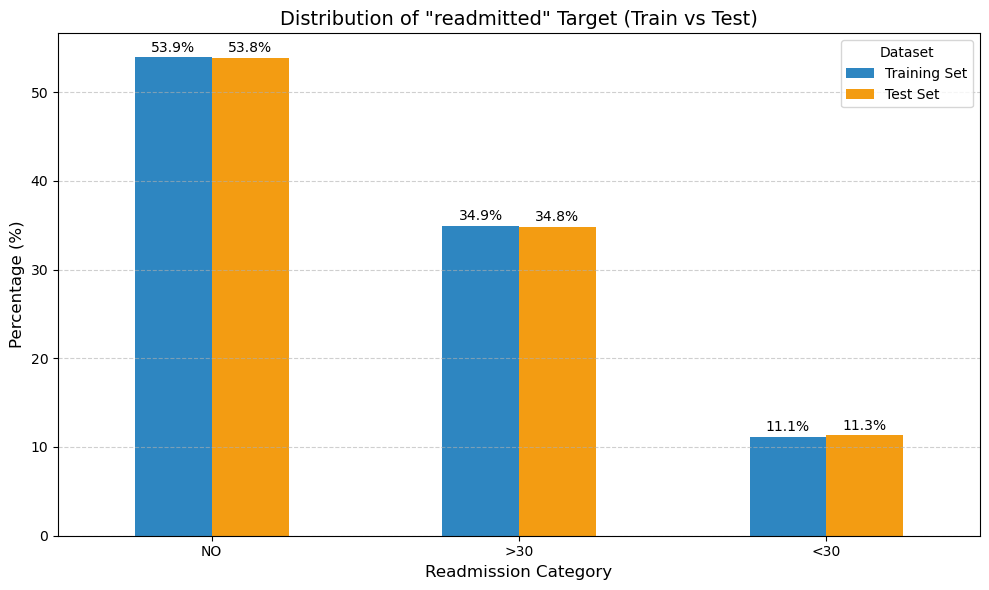

## Add Split Logic
---
## Preprocessing Should Happen for both training and test datasets

In [52]:
df = pd.read_csv('training_data.csv')
df.head()

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,83148,259912530,88114716,Caucasian,Female,[60-70),?,1,6,7,1,MC,?,34,0,10,6,0,0,490,427,571,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
1,8067,37094196,604017,Caucasian,Female,[60-70),?,1,1,7,2,?,Family/GeneralPractice,39,0,11,0,0,0,428,250,305,4,NaN,NaN,Steady,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO
2,19623,69819834,3401055,AfricanAmerican,Female,[40-50),?,1,6,7,5,?,Family/GeneralPractice,63,1,11,1,0,11,535,285,585,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30
3,77236,234245010,71780013,Caucasian,Male,[70-80),?,2,6,1,2,MC,?,39,0,22,3,0,2,482,428,585,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
4,55677,160693860,82716489,Caucasian,Female,[80-90),?,6,3,7,12,?,InternalMedicine,71,1,15,0,0,0,733,584,682,6,Norm,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30


<Axes: >

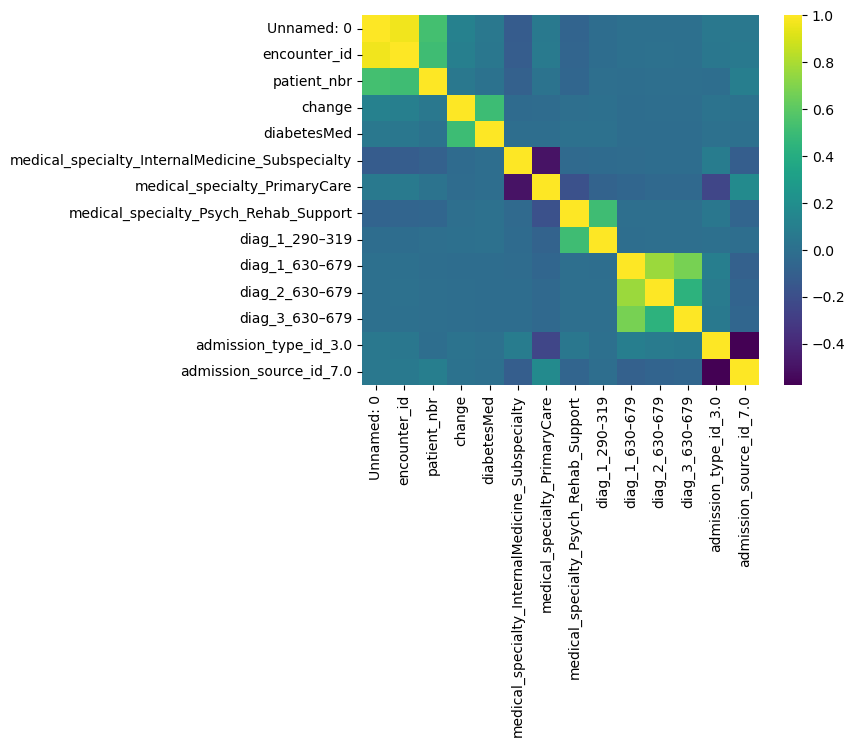

In [88]:
min_thresh = 0.5
corr_matrix = df_6.corr(numeric_only=True)
high_corr_features = corr_matrix.index[(abs(corr_matrix) >= min_thresh).sum() > 1]
high_corr_matrix = corr_matrix.loc[high_corr_features, high_corr_features]
sns.heatmap(high_corr_matrix, cmap='viridis')

1. Our data has way too many features (155), our KNN model will suffer from the curse of dimensionality and will not give us an accurate model.     
2. We want to aim to around ~50 features      
3. We can combat this by feature selection, to reduce high-dimensional data into a lower-dimensional space before doing our KNN algorithms


## End of Exploratory Data Analysis
---
## Start of Model Building

## K-Nearest Neighbors

### Ideas before approaching this problem

### Pre Processing Step:
1. Our data has way too many features (155), our KNN model will suffer from the curse of dimensionality and will not give us an accurate model.   
1.a. We want to aim to around ~50 features
1.b. We can combat this by feature selection, to reduce high-dimensional data into a lower-dimensional space before doing our KNN algorithms

### Overall pipe-line:
1. Split data
2. Drop near-constant features (noise reduction)
3. Log transform numeric features
4. Scaling
5. Dimension Reduction (Feature selection) or use PCA (Principal Component Analysis)
6. Train KNN
7. Finalize with tuning hyperparameters and evaluate

In [27]:
"""
ISSUE: Our encoding made our `readmitted` column into 2 separate ones,
    reconstruct them back for our response variable
"""



'\nISSUE: Our encoding made our `readmitted` column into 2 separate ones,\n    reconstruct them back for our response variable\n'

In [28]:
"""
Splitting Data
"""
X = df_6.drop(columns=["readmitted"])
y = df_6["readmitted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.9, test_size=.1, shuffle=True, random_state=seed)
X_train.shape

(82430, 153)

In [30]:
# Dropping columns based on train data
data_train = X_train.drop(columns=cols_to_drop)
data_test = X_test.drop(columns=cols_to_drop)

data_train.shape

(82430, 96)

In [31]:
"""
Log-transform numeric features
"""

# Separate numeric/binary/low cardinal features

# Numeric cols
numeric_cols = data_train